In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [17]:
DATA_PATH = "/content/train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.000,Unf,0.000,441.000,"1,080.000",GasA,Fa,Y,SBrkr,1656,0,0,1656,1.000,0.000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.000",Fin,2.000,528.000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.000,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.000,Gd,TA,CBlock,TA,TA,No,ALQ,"1,065.000",Unf,0.000,"1,045.000","2,110.000",GasA,Ex,Y,SBrkr,2110,0,0,2110,1.000,0.000,2,1,3,1,Ex,8,Typ,2,TA,Attchd,"1,968.000",Fin,2.000,522.000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [18]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nTarget column present:", "SalePrice" in df.columns)

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T.head(20))

Rows: 2930
Columns: 82

Target column present: True

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,"2,930.000",NaN,NaN,NaN,"1,465.500",845.962,1.000,733.250,"1,465.500","2,197.750","2,930.000"
PID,"2,930.000",NaN,NaN,NaN,"714,464,496.989","188,730,844.649","526,301,100.000","528,477,022.500","535,453,620.000","907,181,097.500","1,007,100,110.000"
MS SubClass,"2,930.000",NaN,NaN,NaN,57.387,42.638,20.000,20.000,50.000,70.000,190.000
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,"2,440.000",NaN,NaN,NaN,69.225,23.365,21.000,58.000,68.000,80.000,313.000
Lot Area,"2,930.000",NaN,NaN,NaN,"10,147.922","7,880.018","1,300.000","7,440.250","9,436.500","11,555.250","215,245.000"
Street,2930,2,Pave,2918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,198,2,Grvl,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Shape,2930,4,Reg,1859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land Contour,2930,4,Lvl,2633,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing.head(20).to_frame("MissingValues"))

,MissingValues
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Cond,159
Garage Yr Blt,159


In [20]:
TARGET = "SalePrice"

X = df.drop(columns=[TARGET]).copy()

y = df[TARGET].copy()

if "Id" in X.columns:
    X = X.drop(columns=["Id"])

print("Predictor shape:", X.shape)

print("Target shape:", y.shape)

Predictor shape: (2930, 81)
Target shape: (2930,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2344
Testing samples: 586


In [22]:
core_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "TotRms AbvGrd",
    "Garage Area"
]

additional_features = [
    "Overall Cond",
    "Bedroom AbvGr",
    "Fireplaces",
    "Garage Yr Blt",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "Bsmt Unf SF",
    "2nd Flr SF",
    "Wood Deck SF",
    "Open Porch SF"
]

expanded_features = core_features + additional_features

print("Core features:", len(core_features))

print("Expanded features:", len(expanded_features))

Core features: 10
Expanded features: 20


In [23]:
rng = np.random.RandomState(RANDOM_STATE)

X_experiment = X.copy()

random_features = []

for i in range(10):

    feature_name = f"RandomFeature_{i+1}"

    X_experiment[feature_name] = rng.normal(
        0,
        1,
        len(X_experiment)
    )

    random_features.append(feature_name)

print("Irrelevant features created:")
print(random_features)

Irrelevant features created:
['RandomFeature_1', 'RandomFeature_2', 'RandomFeature_3', 'RandomFeature_4', 'RandomFeature_5', 'RandomFeature_6', 'RandomFeature_7', 'RandomFeature_8', 'RandomFeature_9', 'RandomFeature_10']


In [24]:
rng = np.random.RandomState(RANDOM_STATE)

redundant_specs = {
    "Redundant_GrLivArea": ("Gr Liv Area", 1.02, 10),
    "Redundant_OverallQual": ("Overall Qual", 1.00, 0.20),
    "Redundant_GarageArea": ("Garage Area", 1.01, 5),
    "Redundant_TotalBsmtSF": ("Total Bsmt SF", 0.99, 10),
    "Redundant_YearBuilt": ("Year Built", 1.00, 2)
}

redundant_features = []

for new_name, (original_name, multiplier, noise) in redundant_specs.items():

    X_experiment[new_name] = (
        X_experiment[original_name] * multiplier
        + rng.normal(0, noise, len(X_experiment))
    )

    redundant_features.append(new_name)

print("Redundant features created:")
print(redundant_features)

Redundant features created:
['Redundant_GrLivArea', 'Redundant_OverallQual', 'Redundant_GarageArea', 'Redundant_TotalBsmtSF', 'Redundant_YearBuilt']


In [25]:
redundancy_evidence = []

for new_name, (original_name, _, _) in redundant_specs.items():

    correlation = X_experiment[original_name].corr(
        X_experiment[new_name]
    )

    redundancy_evidence.append({
        "Original Feature": original_name,
        "Redundant Feature": new_name,
        "Pearson Correlation": correlation
    })

redundancy_df = pd.DataFrame(redundancy_evidence)

display(redundancy_df.round(4))

,Original Feature,Redundant Feature,Pearson Correlation
0,Gr Liv Area,Redundant_GrLivArea,1.000
1,Overall Qual,Redundant_OverallQual,0.990
2,Garage Area,Redundant_GarageArea,1.000
3,Total Bsmt SF,Redundant_TotalBsmtSF,1.000
4,Year Built,Redundant_YearBuilt,0.998


In [26]:
all_original_features = list(X.columns)

feature_sets = {

    "A_Core_10":
        core_features,

    "B_Informative_20":
        expanded_features,

    "C_All_Original":
        all_original_features,

    "D_Original_Plus_Irrelevant":
        all_original_features + random_features,

    "E_Original_Plus_Redundant":
        all_original_features + redundant_features,

    "F_Original_Plus_Both":
        all_original_features
        + random_features
        + redundant_features
}

feature_summary = pd.DataFrame([
    {
        "Experiment": name,

        "Raw Feature Count": len(features),

        "Added Feature Type": {

            "A_Core_10":
                "None — baseline",

            "B_Informative_20":
                "10 additional informative",

            "C_All_Original":
                "Remaining original features",

            "D_Original_Plus_Irrelevant":
                "10 irrelevant random",

            "E_Original_Plus_Redundant":
                "5 redundant",

            "F_Original_Plus_Both":
                "10 irrelevant + 5 redundant"

        }[name]
    }

    for name, features in feature_sets.items()
])

display(feature_summary)

,Experiment,Raw Feature Count,Added Feature Type
0,A_Core_10,10,None — baseline
1,B_Informative_20,20,10 additional informative
2,C_All_Original,81,Remaining original features
3,D_Original_Plus_Irrelevant,91,10 irrelevant random
4,E_Original_Plus_Redundant,86,5 redundant
5,F_Original_Plus_Both,96,10 irrelevant + 5 redundant


In [27]:
def create_preprocessor(X_data, scale_numeric=True):

    numeric_features = X_data.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_features = X_data.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if scale_numeric:
        numeric_steps.append(
            ("scaler", StandardScaler())
        )

    numeric_pipeline = Pipeline(numeric_steps)

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ])

    transformers = []

    if numeric_features:
        transformers.append(
            ("num", numeric_pipeline, numeric_features)
        )

    if categorical_features:
        transformers.append(
            ("cat", categorical_pipeline, categorical_features)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

In [28]:
def make_models():

    return {

        "Linear Regression":
            LinearRegression(),

        "Decision Tree":
            DecisionTreeRegressor(
                random_state=RANDOM_STATE,
                max_depth=10
            )
    }

In [29]:
def evaluate_single_split(
    model,
    X_train_exp,
    X_test_exp,
    y_train,
    y_test
):

    model.fit(X_train_exp, y_train)

    train_pred = model.predict(X_train_exp)

    test_pred = model.predict(X_test_exp)

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    return {

        "Train_RMSE":
            train_rmse,

        "Test_RMSE":
            test_rmse,

        "Test_MAE":
            test_mae,

        "Test_R2":
            test_r2,

        "Generalization_Gap":
            test_rmse - train_rmse
    }

In [30]:
main_results = []

for experiment_name, features in feature_sets.items():

    X_train_exp = X_experiment.loc[
        X_train.index,
        features
    ].copy()

    X_test_exp = X_experiment.loc[
        X_test.index,
        features
    ].copy()

    for model_name, estimator in make_models().items():

        preprocessor = create_preprocessor(
            X_train_exp,

            scale_numeric=(
                model_name == "Linear Regression"
            )
        )

        pipeline = Pipeline([
            ("preprocessing", preprocessor),
            ("model", estimator)
        ])

        metrics = evaluate_single_split(
            pipeline,
            X_train_exp,
            X_test_exp,
            y_train,
            y_test
        )

        fitted_preprocessor = (
            pipeline.named_steps["preprocessing"]
        )

        transformed_count = len(
            fitted_preprocessor
            .get_feature_names_out()
        )

        main_results.append({

            "Experiment":
                experiment_name,

            "Model":
                model_name,

            "Raw_Features":
                len(features),

            "Transformed_Features":
                transformed_count,

            **metrics
        })

main_results_df = pd.DataFrame(main_results)

display(
    main_results_df
    .sort_values(
        ["Model", "Experiment"]
    )
    .round(3)
)

,Experiment,Model,Raw_Features,Transformed_Features,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Generalization_Gap
1,A_Core_10,Decision Tree,10,10,"13,621.961","41,998.385","24,378.259",0.780,"28,376.424"
3,B_Informative_20,Decision Tree,20,20,"12,374.952","36,402.288","22,809.144",0.835,"24,027.336"
5,C_All_Original,Decision Tree,81,302,"11,578.378","34,254.271","23,189.124",0.854,"22,675.894"
7,D_Original_Plus_Irrelevant,Decision Tree,91,312,"11,197.933","33,237.156","23,235.072",0.862,"22,039.222"
9,E_Original_Plus_Redundant,Decision Tree,86,307,"10,875.005","32,601.637","21,911.669",0.867,"21,726.631"
11,F_Original_Plus_Both,Decision Tree,96,317,"10,688.709","34,178.892","22,349.504",0.854,"23,490.183"
0,A_Core_10,Linear Regression,10,10,"35,287.394","39,562.049","24,856.124",0.805,"4,274.655"
2,B_Informative_20,Linear Regression,20,20,"33,466.212","36,630.356","22,361.658",0.833,"3,164.145"
4,C_All_Original,Linear Regression,81,302,"18,972.640","29,635.359","16,034.108",0.890,"10,662.719"
6,D_Original_Plus_Irrelevant,Linear Regression,91,312,"18,920.201","29,635.504","15,974.995",0.890,"10,715.303"


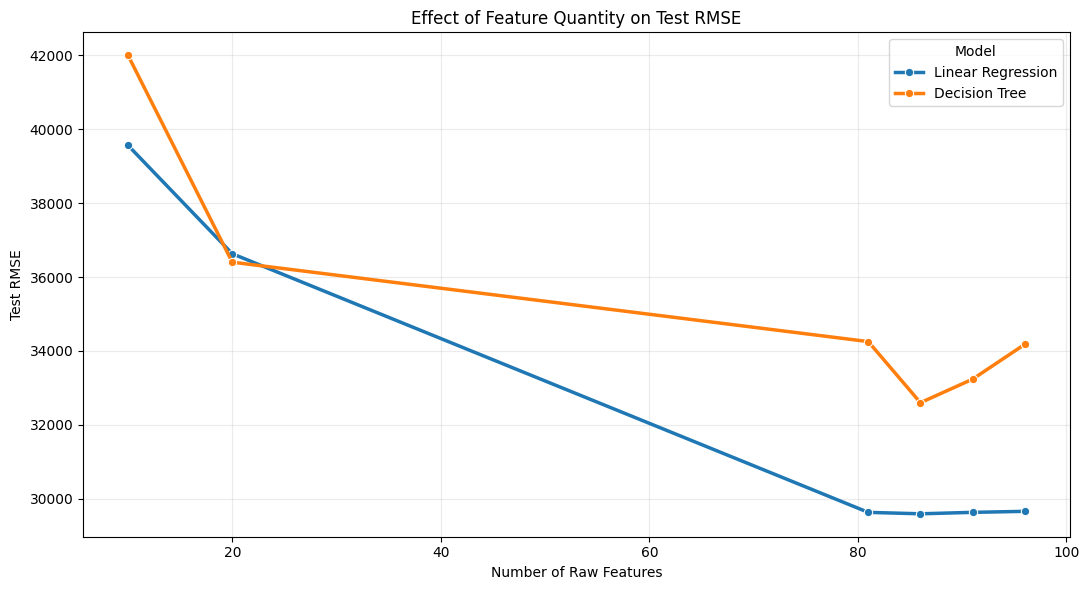

In [31]:
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=main_results_df,
    x="Raw_Features",
    y="Test_RMSE",
    hue="Model",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Effect of Feature Quantity on Test RMSE"
)

plt.xlabel("Number of Raw Features")

plt.ylabel("Test RMSE")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

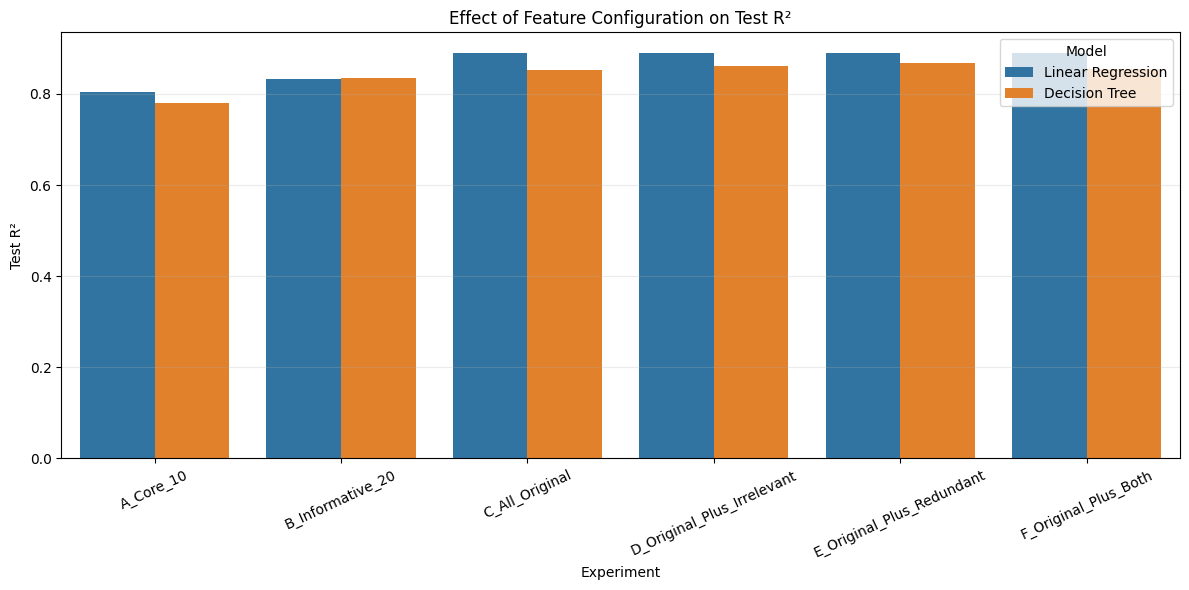

In [32]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=main_results_df,
    x="Experiment",
    y="Test_R2",
    hue="Model"
)

plt.title(
    "Effect of Feature Configuration on Test R²"
)

plt.xlabel("Experiment")

plt.ylabel("Test R²")

plt.xticks(rotation=25)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()

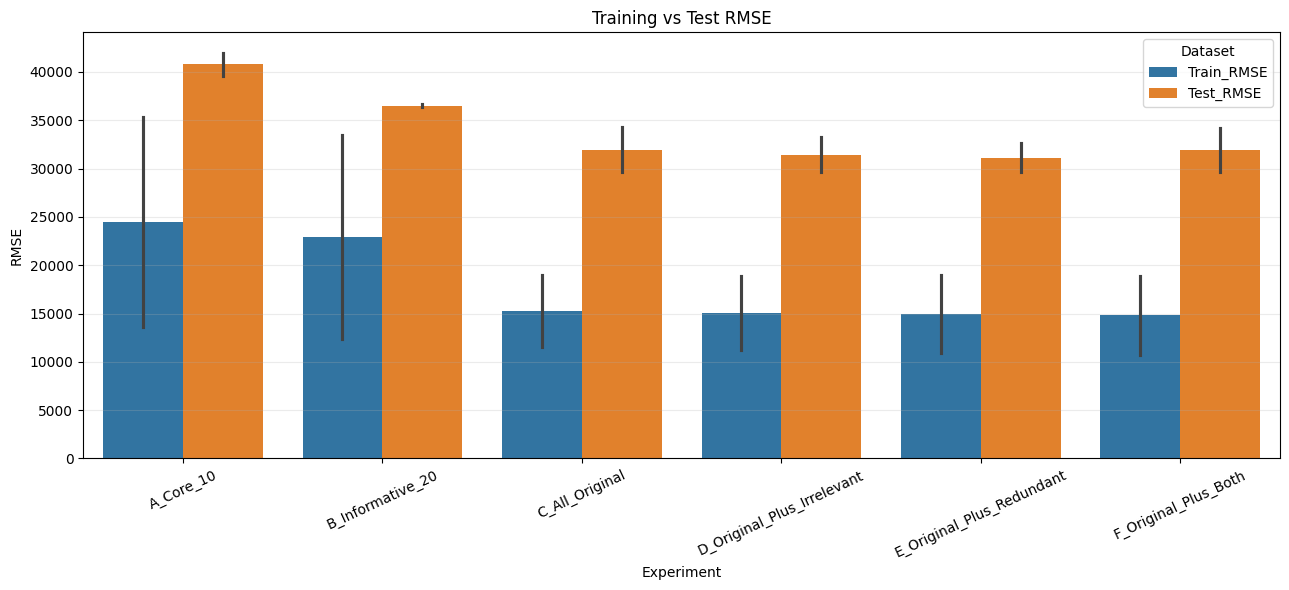

In [33]:
plot_df = main_results_df.melt(
    id_vars=[
        "Experiment",
        "Model"
    ],

    value_vars=[
        "Train_RMSE",
        "Test_RMSE"
    ],

    var_name="Dataset",

    value_name="RMSE"
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=plot_df,
    x="Experiment",
    y="RMSE",
    hue="Dataset"
)

plt.title(
    "Training vs Test RMSE"
)

plt.xlabel("Experiment")

plt.ylabel("RMSE")

plt.xticks(rotation=25)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()

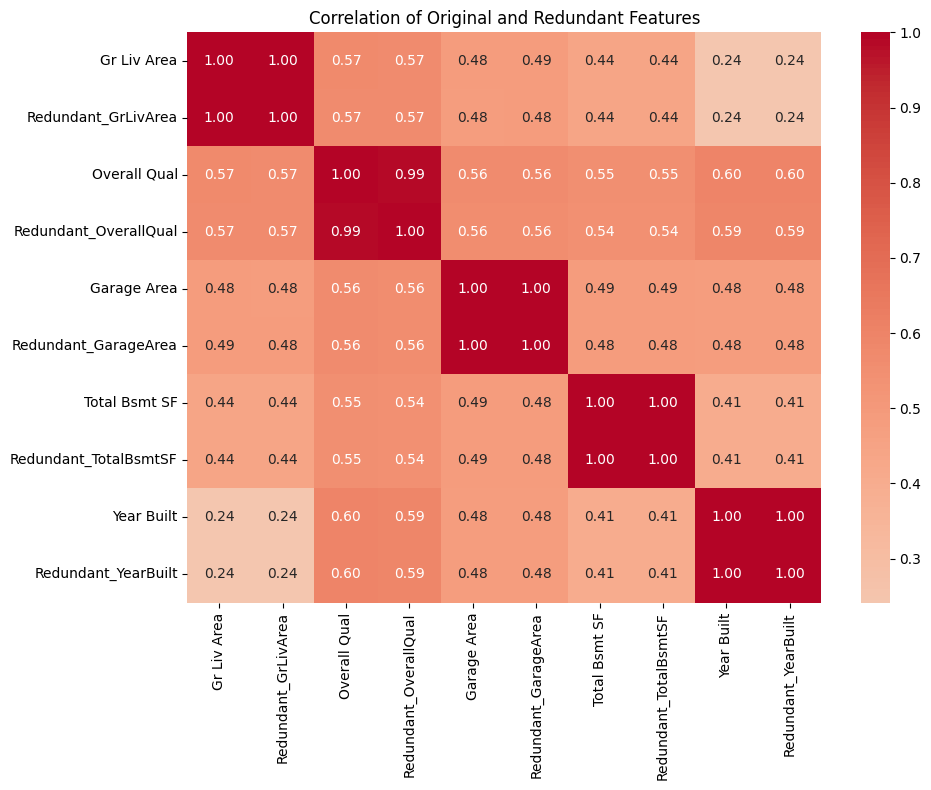

In [34]:
corr_features = []

for original_name, new_name, _ in [
    (v[0], k, None)
    for k, v in redundant_specs.items()
]:

    corr_features.extend([
        original_name,
        new_name
    ])

corr_features = list(
    dict.fromkeys(corr_features)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    X_experiment[corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation of Original and Redundant Features"
)

plt.tight_layout()

plt.show()

In [35]:
comparison_pairs = [

    (
        "A_Core_10",
        "B_Informative_20",
        "Additional informative features"
    ),

    (
        "C_All_Original",
        "D_Original_Plus_Irrelevant",
        "Additional irrelevant features"
    ),

    (
        "C_All_Original",
        "E_Original_Plus_Redundant",
        "Additional redundant features"
    ),

    (
        "C_All_Original",
        "F_Original_Plus_Both",
        "Irrelevant + redundant features"
    )
]

comparison_rows = []

for base, modified, change_description in comparison_pairs:

    for model_name in main_results_df["Model"].unique():

        base_row = main_results_df[
            (main_results_df["Experiment"] == base) &
            (main_results_df["Model"] == model_name)
        ].iloc[0]

        modified_row = main_results_df[
            (main_results_df["Experiment"] == modified) &
            (main_results_df["Model"] == model_name)
        ].iloc[0]

        comparison_rows.append({

            "Model":
                model_name,

            "Comparison":
                f"{base} → {modified}",

            "Feature Change":
                change_description,

            "Δ Test RMSE":
                modified_row["Test_RMSE"]
                - base_row["Test_RMSE"],

            "Δ Test MAE":
                modified_row["Test_MAE"]
                - base_row["Test_MAE"],

            "Δ Test R²":
                modified_row["Test_R2"]
                - base_row["Test_R2"],

            "Δ Generalization Gap":
                modified_row["Generalization_Gap"]
                - base_row["Generalization_Gap"]
        })

comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    comparison_df.round(3)
)

,Model,Comparison,Feature Change,Δ Test RMSE,Δ Test MAE,Δ Test R²,Δ Generalization Gap
0,Linear Regression,A_Core_10 → B_Informative_20,Additional informative features,"-2,931.693","-2,494.467",0.028,"-1,110.510"
1,Decision Tree,A_Core_10 → B_Informative_20,Additional informative features,"-5,596.097","-1,569.115",0.055,"-4,349.088"
2,Linear Regression,C_All_Original → D_Original_Plus_Irrelevant,Additional irrelevant features,0.145,-59.112,-0.000,52.584
3,Decision Tree,C_All_Original → D_Original_Plus_Irrelevant,Additional irrelevant features,"-1,017.116",45.948,0.009,-636.671
4,Linear Regression,C_All_Original → E_Original_Plus_Redundant,Additional redundant features,-38.659,-30.298,0.000,-9.490
5,Decision Tree,C_All_Original → E_Original_Plus_Redundant,Additional redundant features,"-1,652.635","-1,277.455",0.014,-949.262
6,Linear Regression,C_All_Original → F_Original_Plus_Both,Irrelevant + redundant features,28.100,-42.239,-0.000,87.951
7,Decision Tree,C_All_Original → F_Original_Plus_Both,Irrelevant + redundant features,-75.380,-839.620,0.001,814.290
